In [21]:
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns
import re
import io

# Graphics test "Light"

In [13]:
# Pattern to match your uploaded files
FILE_PATTERN = "../results/failure_margins_delta_*.txt"
TOTAL_IMAGES = 20  # Total number of images in the dataset

def load_data(pattern):
    files = glob.glob(pattern)
    if not files:
        print("Error: No files found. Check your directory.")
        return pd.DataFrame()

    print(f"Processing {len(files)} files...")
    df_list = []

    for filename in files:
        # 1. Extract Delta from filename
        # Expecting format like: ...delta_0.002...
        match = re.search(r'delta_(\d+\.\d+)', filename)
        if match:
            delta = float(match.group(1))
        else:
            print(f"Warning: Could not extract Delta from {filename}")
            continue

        try:
            # 2. Read CSV directly
            # Format: Image_Index,Class,Failure_Margin
            df_temp = pd.read_csv(filename)
            
            # 3. Add Metadata
            df_temp['Delta'] = delta
            
            # 4. Determine Status
            # Margin == 0.0 -> SAFE
            # Margin > 0.0  -> UNSAFE
            df_temp['Status'] = df_temp['Failure_Margin'].apply(
                lambda x: 'SAFE' if x == 0.0 else 'UNSAFE'
            )
            
            df_list.append(df_temp)
            
        except Exception as e:
            print(f"Error reading {filename}: {e}")

    if not df_list:
        return pd.DataFrame()

    # Combine and Sort
    df_full = pd.concat(df_list, ignore_index=True)
    df_full = df_full.sort_values(by=['Delta', 'Image_Index'])
    
    return df_full

# Load Data
df = load_data(FILE_PATTERN)

if not df.empty:
    print(f"\nData Loaded Successfully! Total rows: {len(df)}")
    print(df.head())
    print("\nDeltas found:", df['Delta'].unique())
else:
    print("DataFrame is empty.")

Processing 4 files...

Data Loaded Successfully! Total rows: 80
   Image_Index  Class  Failure_Margin   Delta Status
0            0      2             0.0  0.0005   SAFE
1            1      5             0.0  0.0005   SAFE
2            2      5             0.0  0.0005   SAFE
3            3      5             0.0  0.0005   SAFE
4            4      5             0.0  0.0005   SAFE

Deltas found: [0.0005 0.001  0.002  0.005 ]


/tmp/ipykernel_9361/759323209.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Delta', y='Safety Rate (%)', data=safety_rates, palette='RdYlGn')


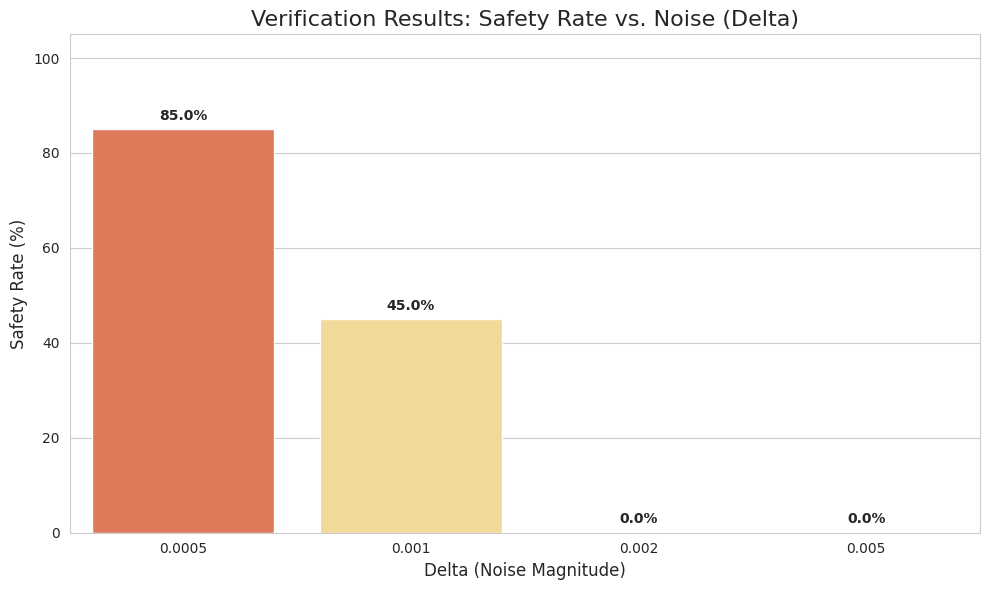

In [15]:
if not df.empty:
    # Calculate % SAFE
    safety_rates = df.groupby('Delta')['Status'].apply(
        lambda x: (x == 'SAFE').mean() * 100
    ).reset_index()
    safety_rates.columns = ['Delta', 'Safety Rate (%)']

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Red-Yellow-Green Palette
    ax = sns.barplot(x='Delta', y='Safety Rate (%)', data=safety_rates, palette='RdYlGn')
    
    plt.title('Verification Results: Safety Rate vs. Noise (Delta)', fontsize=16)
    plt.ylabel('Safety Rate (%)', fontsize=12)
    plt.xlabel('Delta (Noise Magnitude)', fontsize=12)
    plt.ylim(0, 105)
    
    # Add text labels
    for i, row in safety_rates.iterrows():
        ax.text(i, row['Safety Rate (%)'] + 2, 
                f"{row['Safety Rate (%)']:.1f}%", 
                ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## Failure margin analysis with bounds

This graph calculates the mean failure margin, and is also usefull to visualizes the Lower Bound (Min) and Upper Bound (Max) of the margins for each Delta. This shows not just the average error, but the range of uncertainty.

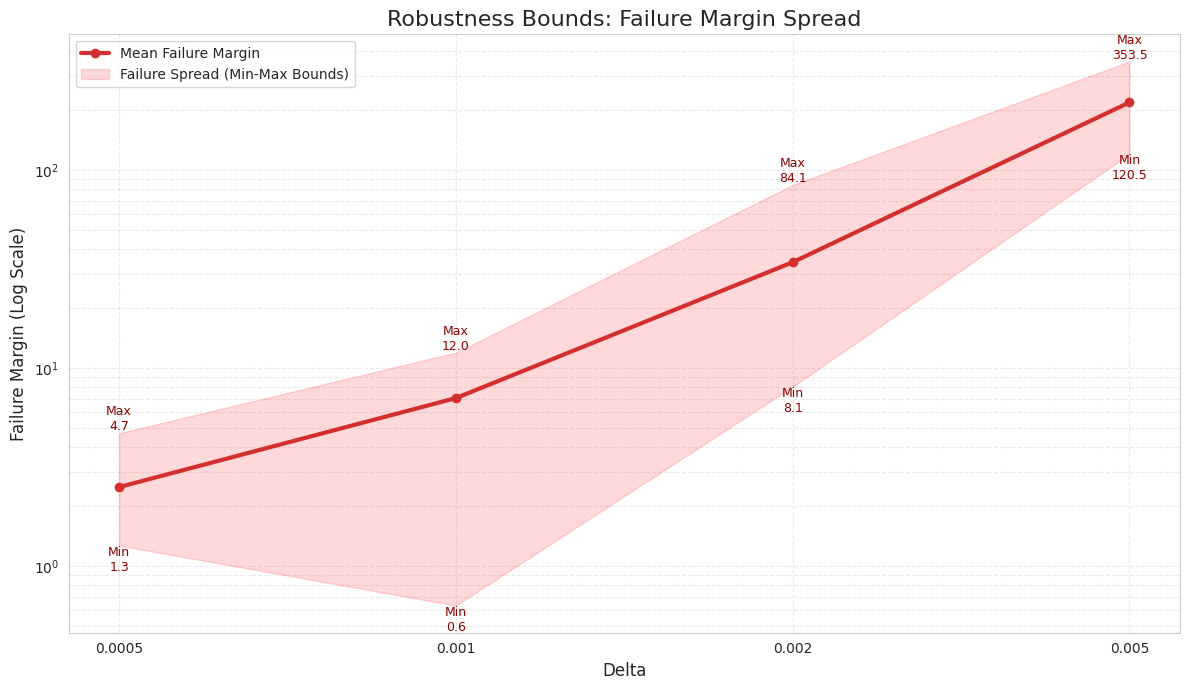

In [16]:
#  MARGIN TRENDS WITH UPPER/LOWER BOUNDS 
if not df.empty:
    # Filter only UNSAFE images (Margin > 0) to analyze the magnitude of failure
    df_unsafe = df[df['Status'] == 'UNSAFE']
    
    if not df_unsafe.empty:
        # Calculate Statistics: Mean, Min (Lower Bound), Max (Upper Bound)
        stats = df_unsafe.groupby('Delta')['Failure_Margin'].agg(['mean', 'min', 'max']).reset_index()
        
        plt.figure(figsize=(12, 7))
        
        # 1. Plot the Mean Line
        plt.plot(stats['Delta'].astype(str), stats['mean'], 
                 marker='o', color='#d32f2f', linewidth=3, label='Mean Failure Margin')
        
        # 2. Fill the area between Lower Bound (Min) and Upper Bound (Max)
        plt.fill_between(stats['Delta'].astype(str), 
                         stats['min'], 
                         stats['max'], 
                         color='red', alpha=0.15, 
                         label='Failure Spread (Min-Max Bounds)')
        
        # Log scale is crucial because margins grow exponentially
        plt.yscale('log')
        
        plt.title('Robustness Bounds: Failure Margin Spread', fontsize=16)
        plt.xlabel('Delta', fontsize=12)
        plt.ylabel('Failure Margin (Log Scale)', fontsize=12)
        plt.grid(True, which="both", ls="--", alpha=0.4)
        plt.legend(loc='upper left')
        
        # Annotate Bounds
        for i, row in stats.iterrows():
            plt.text(i, row['max'], f"Max\n{row['max']:.1f}", ha='center', va='bottom', fontsize=9, color='darkred')
            plt.text(i, row['min'], f"Min\n{row['min']:.1f}", ha='center', va='top', fontsize=9, color='darkred')

        plt.tight_layout()
        plt.show()
    else:
        print("No unsafe images to plot margins.")

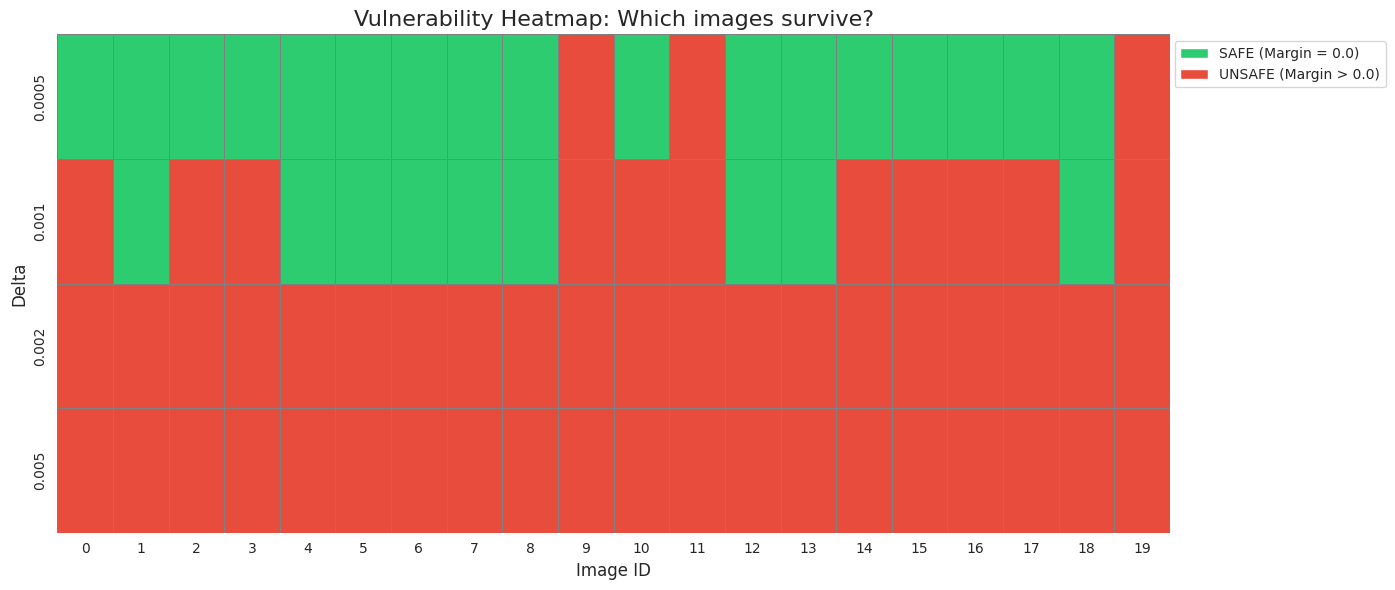

In [ ]:
# SURVIVAL HEATMAP ---
if not df.empty:
    # 1 = SAFE, 0 = UNSAFE
    df['Is_Safe'] = df['Status'].apply(lambda x: 1 if x == 'SAFE' else 0)
    
    # Pivot: Index=Delta, Cols=Image_Index
    pivot = df.pivot(index='Delta', columns='Image_Index', values='Is_Safe')
    
    plt.figure(figsize=(14, 6))
    
    # Custom colors: Red (0) to Green (1)
    cmap = sns.color_palette(['#e74c3c', '#2ecc71']) 
    
    sns.heatmap(pivot, cmap=cmap, cbar=False, linewidths=0.5, linecolor='gray')
    
    plt.title('Vulnerability Heatmap: Which images survive?', fontsize=16)
    plt.ylabel('Delta', fontsize=12)
    plt.xlabel('Image ID', fontsize=12)
    
    # Custom Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='SAFE (Margin = 0.0)'),
        Patch(facecolor='#e74c3c', label='UNSAFE (Margin > 0.0)')
    ]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1))
    
    plt.tight_layout()
    plt.show()

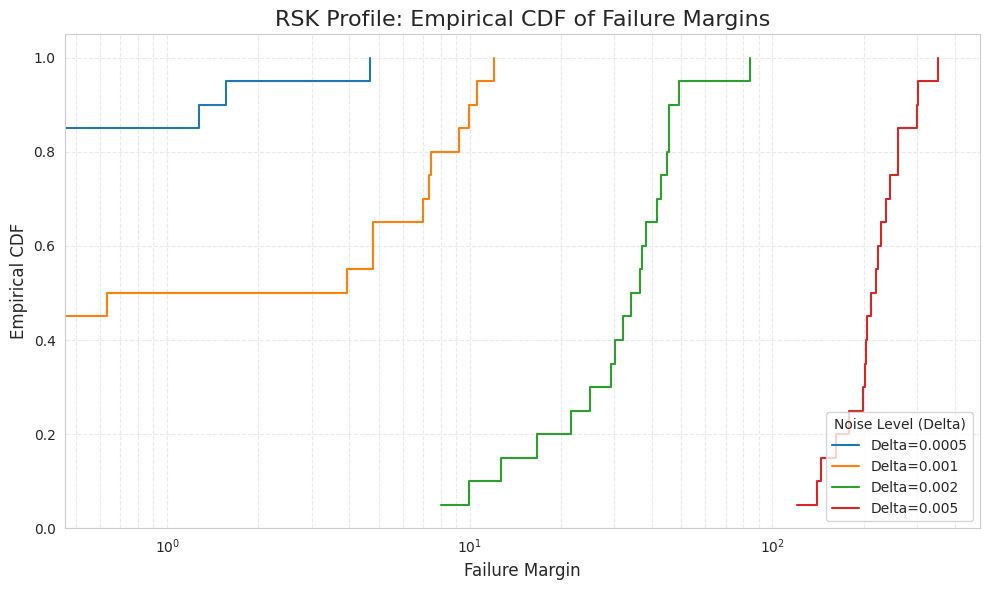

In [18]:
#graphic RSK PROFILE (ECDF - EMPIRICAL CUMULATIVE DISTRIVUTION FUNCTION)
if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    deltas = sorted(df['Delta'].unique())
    
    for delta in deltas:
        subset = df[df['Delta'] == delta]
        margins = subset['Failure_Margin']
        
        # ECDF Calculation
        x = np.sort(margins)
        y = np.arange(1, len(x) + 1) / len(x)
        
        plt.step(x, y, where='post', label=f'Delta={delta}')
    
    plt.title('RSK Profile: Empirical CDF of Failure Margins', fontsize=16)
    plt.xlabel('Failure Margin', fontsize=12)
    plt.ylabel('Empirical CDF', fontsize=12)
    plt.xscale('log')
    plt.ylim(0, 1.05)
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend(title='Noise Level (Delta)', loc='lower right')
    
    plt.tight_layout()
    plt.show()

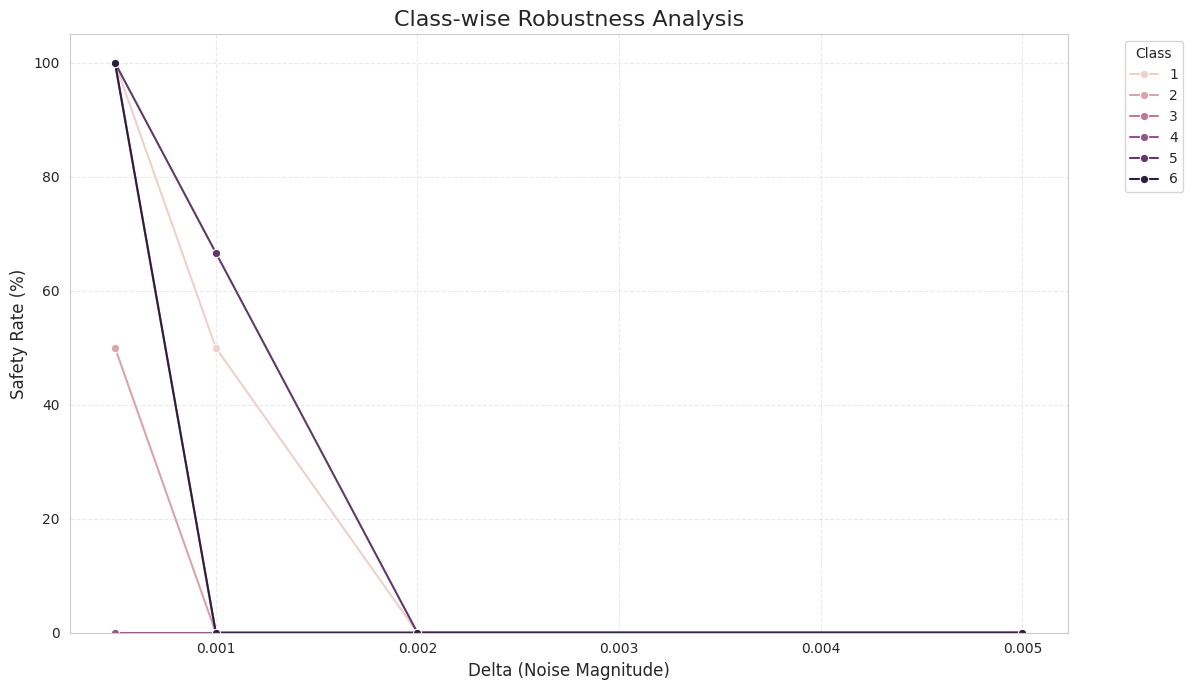

In [19]:
#graphic CLASS-WISE ROBUSTNESS (Bias Analysis)
if not df.empty:
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    class_robustness = df.groupby(['Class', 'Delta'])['Status'].apply(
        lambda x: (x == 'SAFE').mean() * 100
    ).reset_index()
    class_robustness.columns = ['Class', 'Delta', 'Safety Rate (%)']
    
    sns.lineplot(data=class_robustness, x='Delta', y='Safety Rate (%)', hue='Class', marker='o')
    
    plt.title('Class-wise Robustness Analysis', fontsize=16)
    plt.xlabel('Delta (Noise Magnitude)', fontsize=12)
    plt.ylabel('Safety Rate (%)', fontsize=12)
    plt.ylim(0, 105)
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Graphics test robustness rotation

In [25]:

raw_data = "../results/robustness_limits.txt"
with open(raw_data, 'r') as file:
    raw_data = file.read()


df = pd.read_csv(io.StringIO(raw_data), comment='#', header=None, names=['MaxSafeAngle'])
df['Image_Index'] = df.index  # Assign IDs 0-19

class_map = {
    0: 2, 1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 1, 7: 5, 8: 5, 9: 4, 
    10: 3, 11: 2, 12: 5, 13: 5, 14: 5, 15: 6, 16: 5, 17: 1, 18: 5, 19: 4
}
df['Class'] = df['Image_Index'].map(class_map)

print("Geometric Data Loaded!")
print(df.head())

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120


Geometric Data Loaded!
   MaxSafeAngle  Image_Index  Class
0          11.5            0      2
1           7.0            1      5
2           9.0            2      5
3           8.0            3      5
4           7.0            4      5


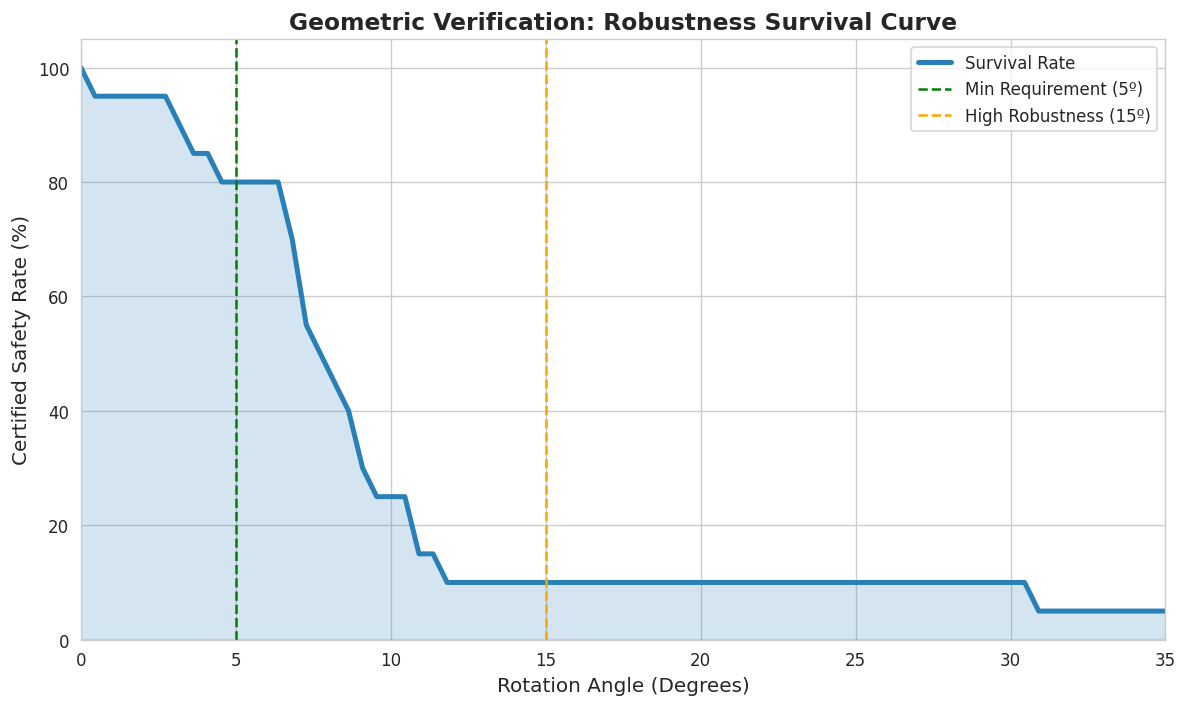

In [27]:

# ==============================================================================
# PLOT 1: ROBUSTNESS SURVIVAL CURVE (The "Geometric Safety Rate")
# Topic: Certification & Verification
# Shows what percentage of the dataset remains verified as rotation increases.
# ==============================================================================
# We calculate the empirical survival function
max_angle = df['MaxSafeAngle'].max()
x_vals = np.linspace(0, max_angle, 100)
survival_rates = [ (df['MaxSafeAngle'] >= x).mean() * 100 for x in x_vals ]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, survival_rates, color='#2980b9', linewidth=3, label='Survival Rate')
plt.fill_between(x_vals, survival_rates, color='#2980b9', alpha=0.2)

# Threshold lines (Standard requirements)
plt.axvline(x=5, color='green', linestyle='--', label='Min Requirement (5º)')
plt.axvline(x=15, color='orange', linestyle='--', label='High Robustness (15º)')

plt.title('Geometric Verification: Robustness Survival Curve', fontsize=14, fontweight='bold')
plt.xlabel('Rotation Angle (Degrees)', fontsize=12)
plt.ylabel('Certified Safety Rate (%)', fontsize=12)
plt.xlim(0, 35) # Focus on relevant range
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()


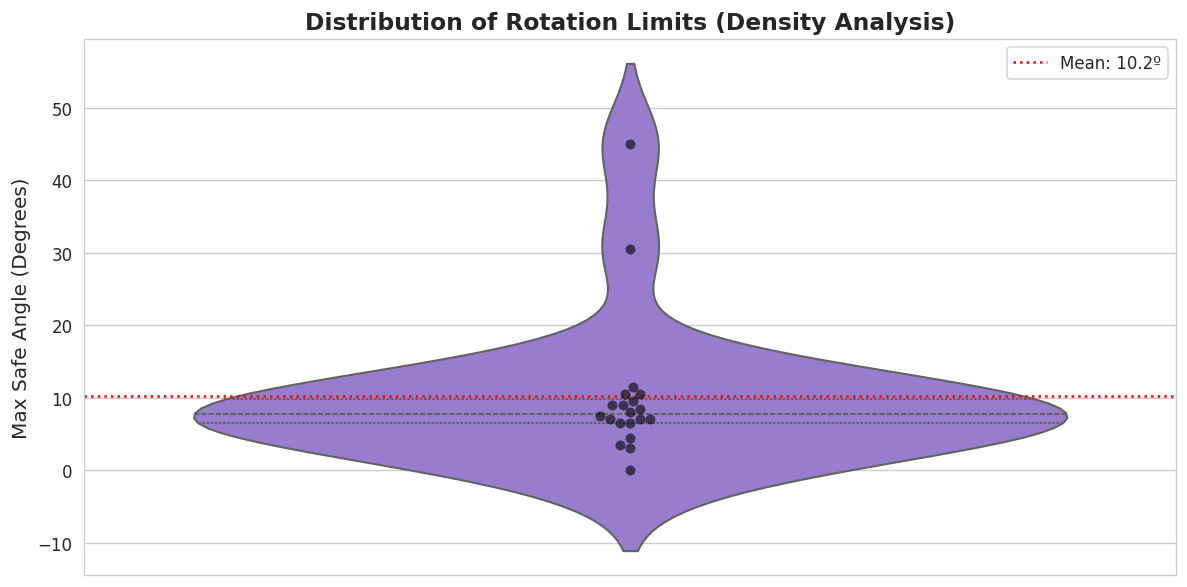

In [29]:

# ==============================================================================
# PLOT 2: ROBUSTNESS DISTRIBUTION (Violin Plot)
# Topic: Statistical Analysis of Robustness
# Visualizes the density of the limits. Are most images weak, or is the distribution bimodal?
# ==============================================================================
plt.figure(figsize=(10, 5))
# We create a dummy "x" to group all data into one violin
sns.violinplot(y=df['MaxSafeAngle'], color='mediumpurple', inner='quartile')
sns.swarmplot(y=df['MaxSafeAngle'], color='black', alpha=0.6, size=6) # Show individual points

plt.title('Distribution of Rotation Limits (Density Analysis)', fontsize=14, fontweight='bold')
plt.ylabel('Max Safe Angle (Degrees)', fontsize=12)

# Annotate Stats
mean_val = df['MaxSafeAngle'].mean()
plt.axhline(mean_val, color='red', linestyle=':', label=f'Mean: {mean_val:.1f}º')
plt.legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_9361/61138346.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image_Index', y='MaxSafeAngle', data=df, palette=colors)


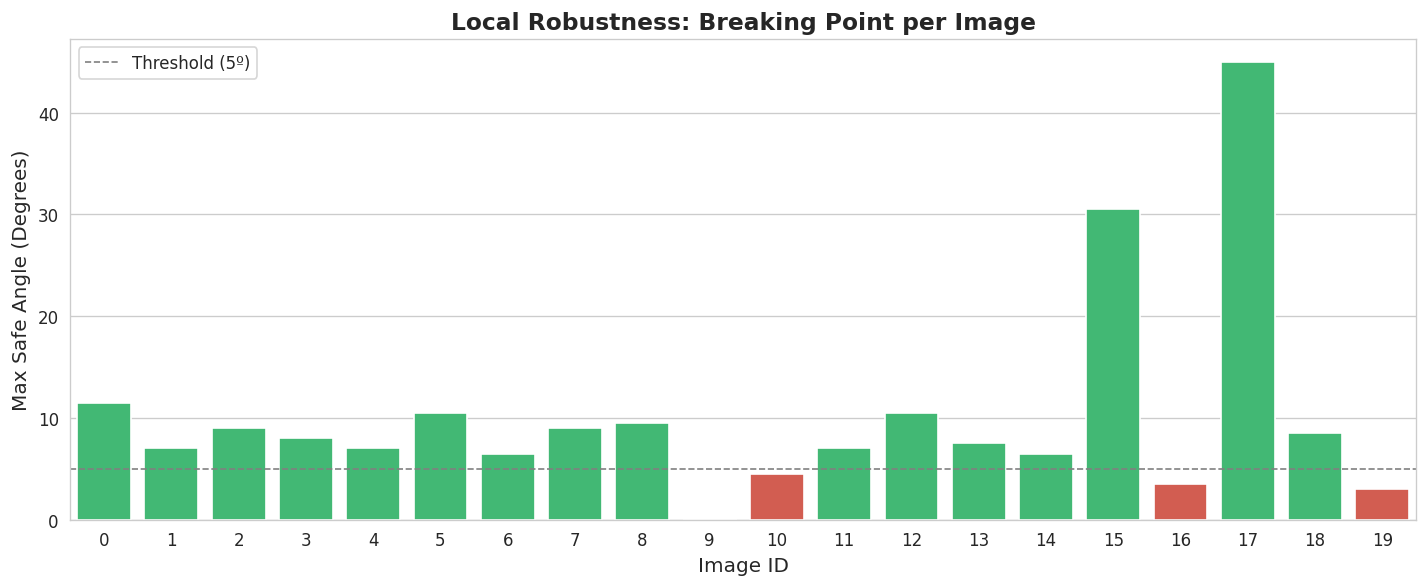

In [31]:

# ==============================================================================
# PLOT 3: PER-IMAGE ROBUSTNESS (Bar Chart)
# Topic: Local Robustness
# Identifies exactly which images are the "weakest links" (e.g., Image 9).
# ==============================================================================
plt.figure(figsize=(12, 5))
# Color bars based on whether they pass a 5-degree check
colors = ['#e74c3c' if x < 5 else '#2ecc71' for x in df['MaxSafeAngle']]

sns.barplot(x='Image_Index', y='MaxSafeAngle', data=df, palette=colors)

plt.axhline(y=5, color='gray', linestyle='--', linewidth=1, label='Threshold (5º)')
plt.title('Local Robustness: Breaking Point per Image', fontsize=14, fontweight='bold')
plt.xlabel('Image ID', fontsize=12)
plt.ylabel('Max Safe Angle (Degrees)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_9361/2030893570.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='MaxSafeAngle', data=class_robustness, palette='magma')


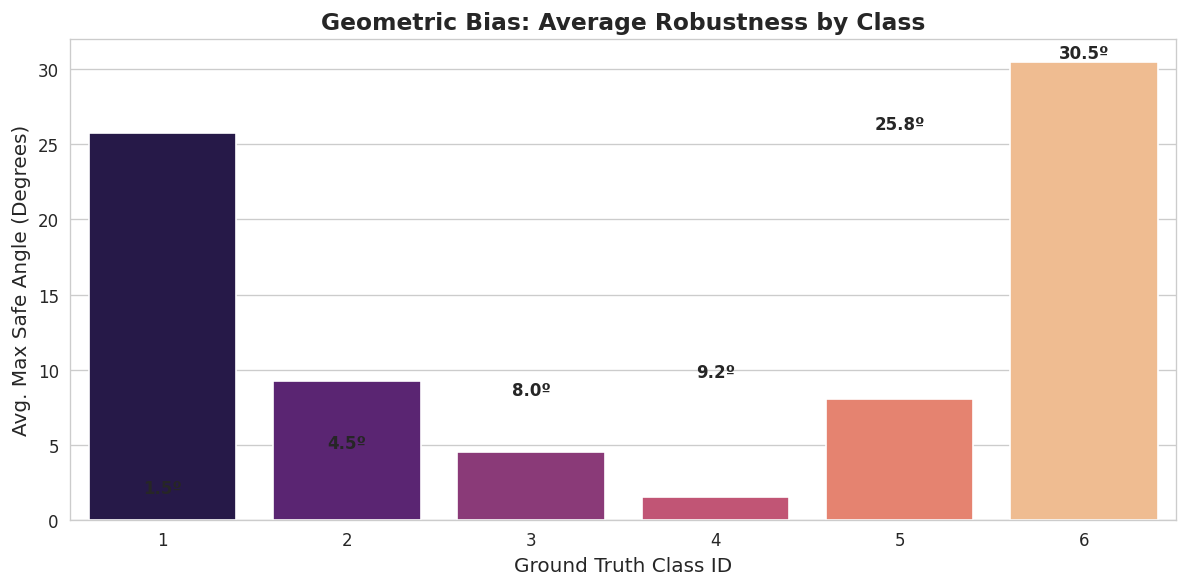

In [33]:
# ==============================================================================
# PLOT 4: CLASS-WISE BIAS (Geometric)
# Topic: Fairness & Bias
# Does the model learn "invariant features" better for some classes than others?
# ==============================================================================
class_robustness = df.groupby('Class')['MaxSafeAngle'].mean().reset_index().sort_values('MaxSafeAngle')

plt.figure(figsize=(10, 5))
sns.barplot(x='Class', y='MaxSafeAngle', data=class_robustness, palette='magma')

plt.title('Geometric Bias: Average Robustness by Class', fontsize=14, fontweight='bold')
plt.xlabel('Ground Truth Class ID', fontsize=12)
plt.ylabel('Avg. Max Safe Angle (Degrees)', fontsize=12)

# Annotate
for i, v in enumerate(class_robustness['MaxSafeAngle']):
    plt.text(i, v, f"{v:.1f}º", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()